## ThinkDSP

This notebook contains code examples from Chapter 4: Noise

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [1]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2025-05-30 19:19:00--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2025-05-30 19:19:00--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2025-05-30 19:19:01 (3.63 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

In [3]:
np.random.seed(17)

The simplest noise to generate is uncorrelated uniform (UU) noise:

In [4]:
from thinkdsp import UncorrelatedUniformNoise

signal = UncorrelatedUniformNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.make_audio()

Here's what a segment of it looks like:

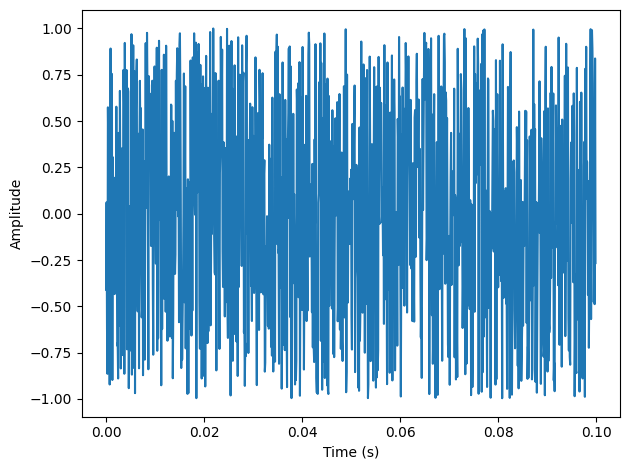

In [5]:
segment = wave.segment(duration=0.1)
segment.plot()
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

And here's the spectrum:

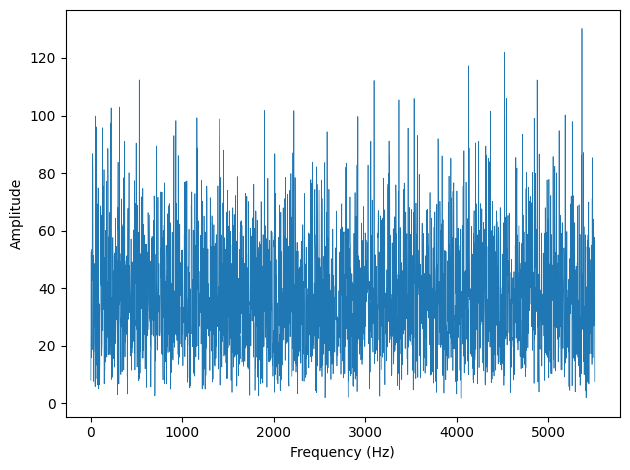

In [6]:
spectrum = wave.make_spectrum()
spectrum.plot(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Amplitude')

In the context of noise it is more conventional to look at the spectrum of power, which is the square of amplitude:

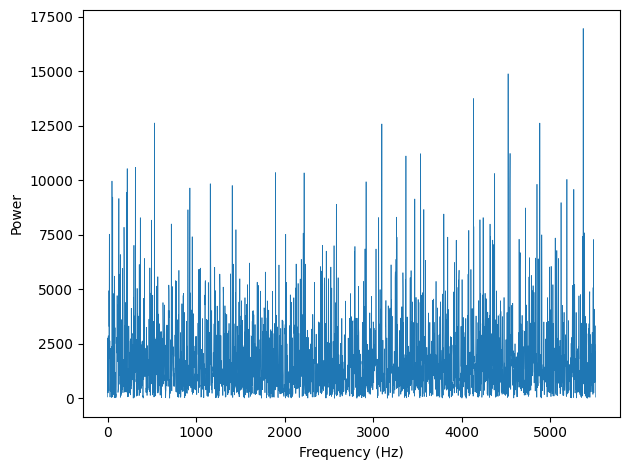

In [7]:
spectrum.plot_power(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

UU noise has the same power at all frequencies, on average, which we can confirm by looking at the normalized cumulative sum of power, which I call an integrated spectrum:

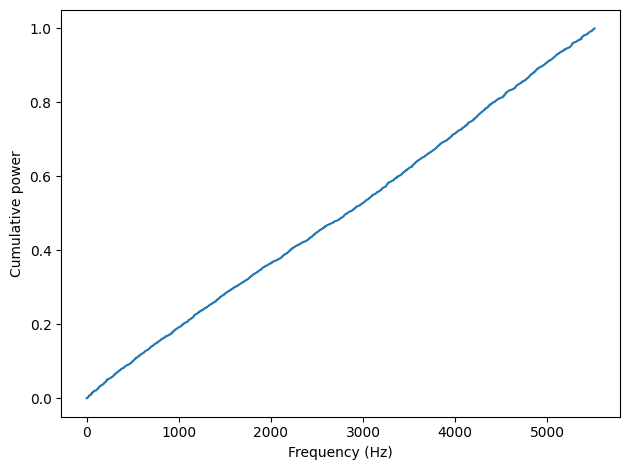

In [8]:
integ = spectrum.make_integrated_spectrum()
integ.plot_power()
decorate(xlabel='Frequency (Hz)',
         ylabel='Cumulative power')

A straight line in this figure indicates that UU noise has equal power at all frequencies, on average.  By analogy with light, noise with this property is called "white noise".

### Brownian noise

Brownian noise is generated by adding up a sequence of random steps.

In [9]:
from thinkdsp import BrownianNoise

signal = BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.make_audio()

The sound is less bright, or more muffled, than white noise.

Here's what the wave looks like:

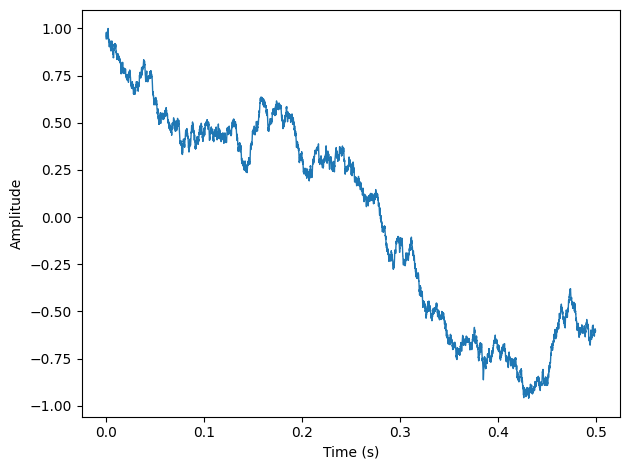

In [10]:
wave.plot(linewidth=1)
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

Here's what the power spectrum looks like on a linear scale.

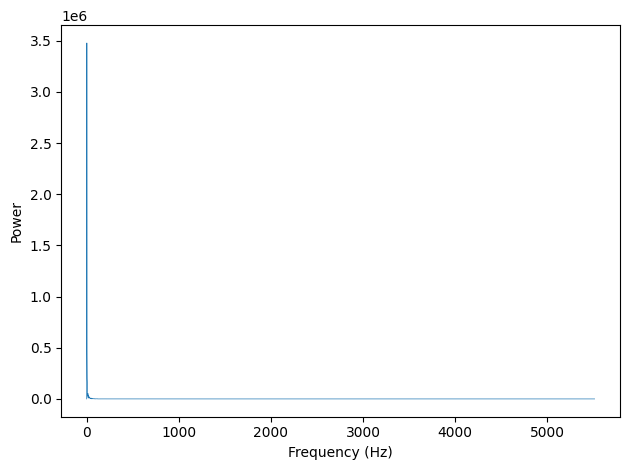

In [11]:
spectrum = wave.make_spectrum()
spectrum.plot_power(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

So much of the energy is at low frequencies, we can't even see the high frequencies.

We can get a better view by plotting the power spectrum on a log-log scale.

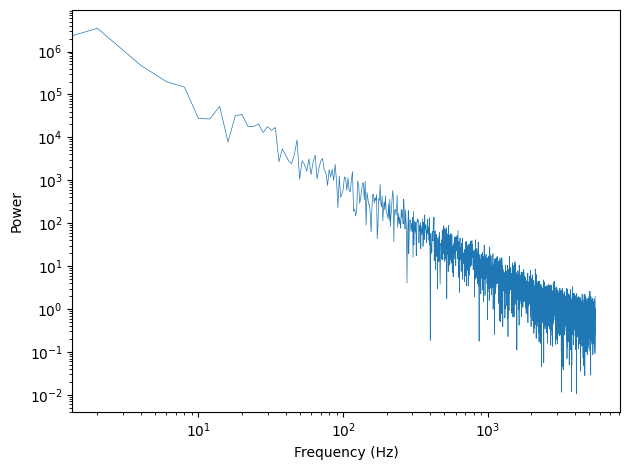

In [12]:
# The f=0 component is very small, so on a log scale
# it's very negative.  If we clobber it before plotting,
# we can see the rest of the spectrum more clearly.
spectrum.hs[0] = 0

spectrum.plot_power(linewidth=0.5)

loglog = dict(xscale='log', yscale='log')
decorate(xlabel='Frequency (Hz)',
         ylabel='Power',
         **loglog)

Now the relationship between power and frequency is clearer.  The slope of this line is approximately -2, which indicates that $P = K / f^2$, for some constant $K$.

In [13]:
signal =  BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
spectrum = wave.make_spectrum()
result = spectrum.estimate_slope()
result.slope

np.float64(-1.7846032211221765)

The estimated slope of the line is closer to -1.8 than -2, for reasons we'll see later.

### Pink noise

Pink noise is characterized by a parameter, $\beta$, usually between 0 and 2.  You can hear the differences below.

With $\beta=0$, we get white noise:

In [14]:
from thinkdsp import PinkNoise

signal = PinkNoise(beta=0)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

With $\beta=1$, pink noise has the relationship $P = K / f$, which is why it is also called $1/f$ noise.

In [15]:
signal = PinkNoise(beta=1)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

With $\beta=2$, we get Brownian (aka red) noise.

In [16]:
signal = PinkNoise(beta=2)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

The following figure shows the power spectrums for white, pink, and red noise on a log-log scale.

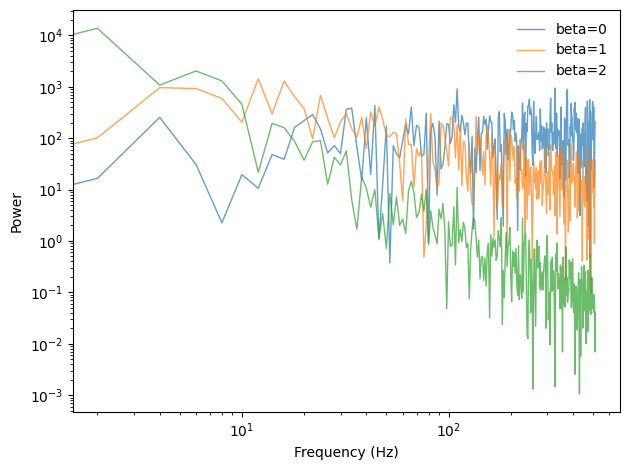

In [17]:
betas = [0, 1, 2]

for beta in betas:
    signal = PinkNoise(beta=beta)
    wave = signal.make_wave(duration=0.5, framerate=1024)
    spectrum = wave.make_spectrum()
    spectrum.hs[0] = 0
    label = f'beta={beta}'
    spectrum.plot_power(linewidth=1, alpha=0.7, label=label)

decorate(xlabel='Frequency (Hz)',
         ylabel='Power',
         **loglog)

### Uncorrelated Gaussian noise

An alternative to UU noise is uncorrelated Gaussian (UG noise).

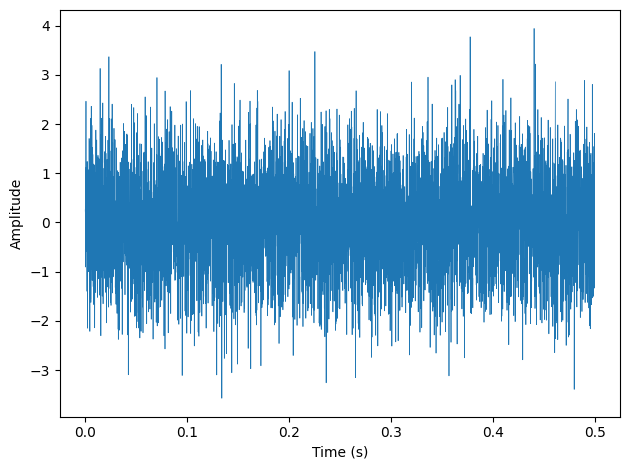

In [18]:
from thinkdsp import UncorrelatedGaussianNoise

signal = UncorrelatedGaussianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.plot(linewidth=0.5)
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

The spectrum of UG noise is also UG noise.

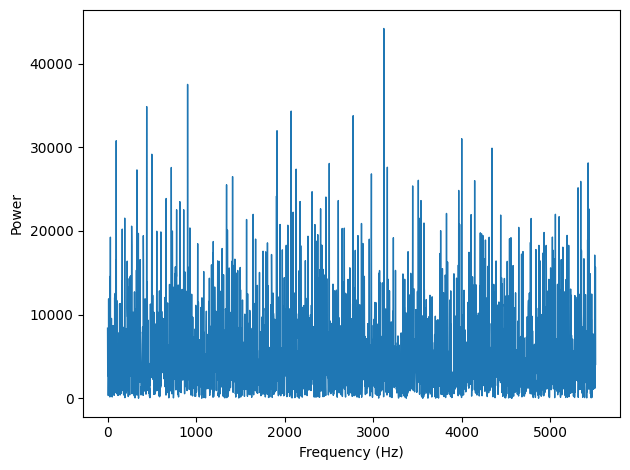

In [19]:
spectrum = wave.make_spectrum()
spectrum.plot_power(linewidth=1)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

We can use a normal probability plot to test the distribution of the power spectrum.

In [20]:
def normal_prob_plot(sample, fit_color='0.8', **options):
    """Makes a normal probability plot with a fitted line.

    sample: sequence of numbers
    fit_color: color string for the fitted line
    options: passed along to Plot
    """
    n = len(sample)
    xs = np.random.normal(0, 1, n)
    xs.sort()

    ys = np.sort(sample)

    mean, std = np.mean(sample), np.std(sample)
    fit_ys = mean + std * xs
    plt.plot(xs, fit_ys, color='gray', alpha=0.5, label='model')

    plt.plot(xs, ys, **options)

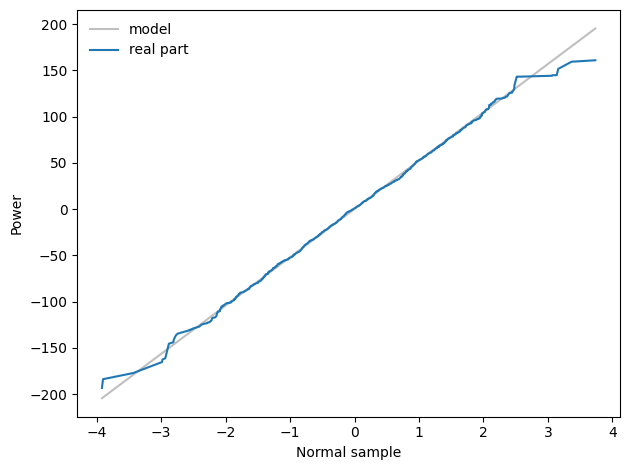

In [21]:
normal_prob_plot(spectrum.real, color='C0', label='real part')
decorate(xlabel='Normal sample',
         ylabel='Power')

A straight line on a normal probability plot indicates that the distribution of the real part of the spectrum is Gaussian.

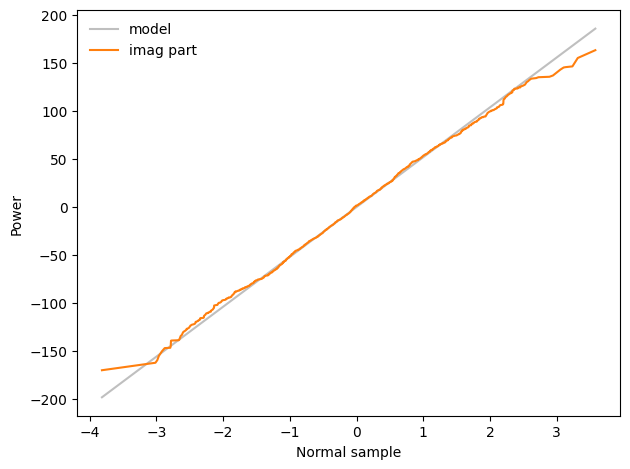

In [22]:
normal_prob_plot(spectrum.imag, color='C1', label='imag part')
decorate(xlabel='Normal sample',
         ylabel='Power')

# **Упражнение 4.1**
На сайте Soft Murmur можно послушать множество природных источников шума, включая дождь, волны, ветер, и др. На веб-странице http://asoftmurmur.com/about/ приведен перечень записей; большинство из них хранится на http://freesound.org.

Скачайте некоторые из этих файлов и вычислите спектры каждого сигнала. Похож ли их спектр мощности на белый, розовый или броуновский шум? Как спектр меняется во времени?

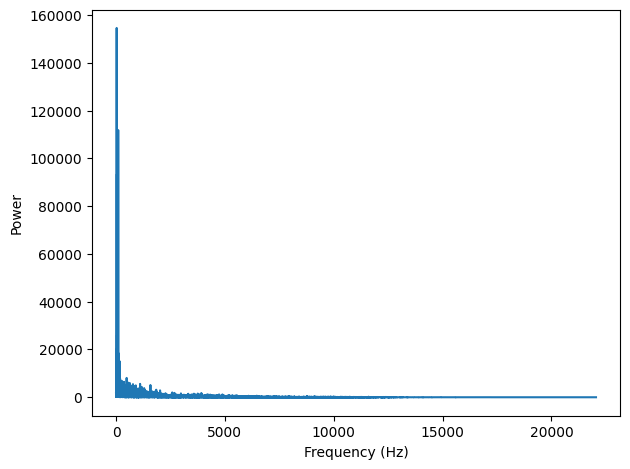

In [24]:
from thinkdsp import read_wave
import numpy as np
import matplotlib.pyplot as plt
from thinkdsp import decorate

rain_wave = read_wave('rain.wav')
rain_segment = rain_wave.segment(start=2.5, duration=1.0)
rain_spectrum = rain_segment.make_spectrum()
rain_spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power')

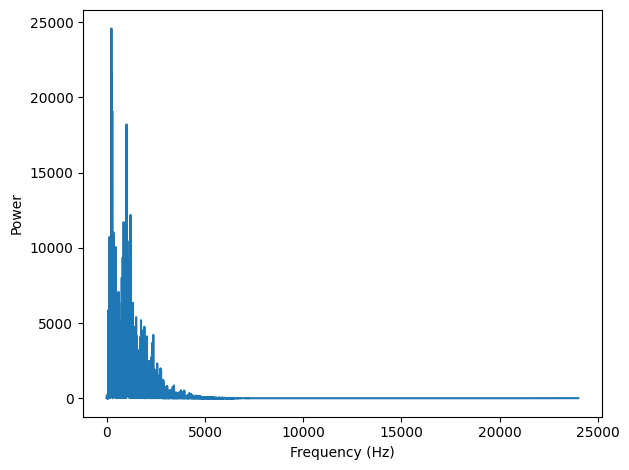

In [25]:
waves_wave = read_wave('waves.wav')
waves_segment = waves_wave.segment(start=1.5, duration=1.0)
waves_spectrum = waves_segment.make_spectrum()
waves_spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power')

Спектры мощностей в логарифмическом формате:

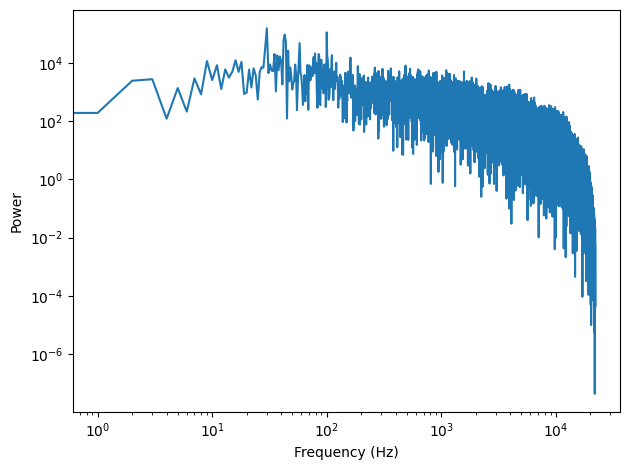

In [26]:
rain_spectrum.plot_power()

loglog = dict(xscale='log', yscale='log')
decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

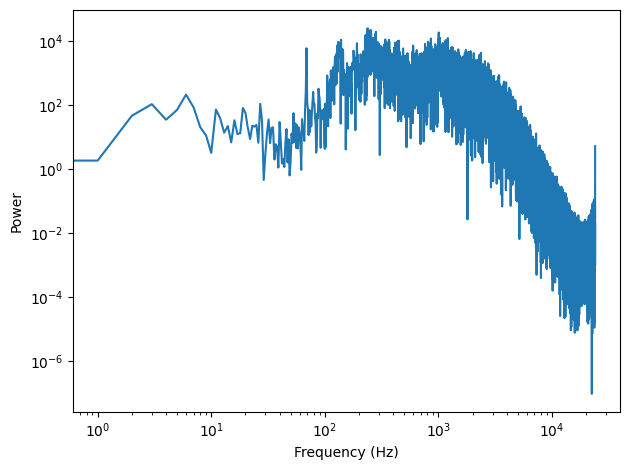

In [27]:
waves_spectrum.plot_power()

loglog = dict(xscale='log', yscale='log')
decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

Спектры мощностей обоих звуков более всего похожи на броуновкий шум.

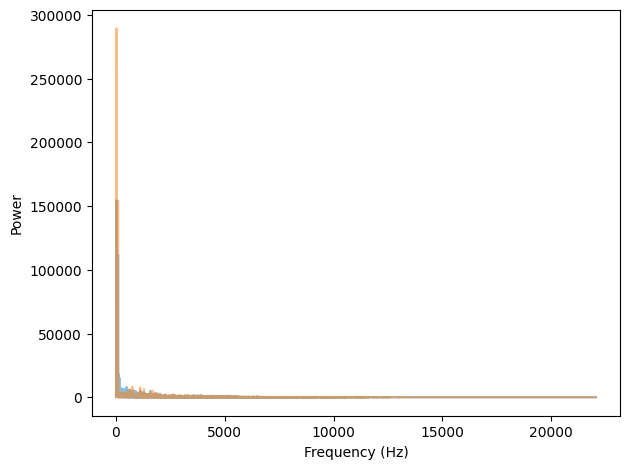

In [28]:
rain_segment2 = rain_wave.segment(start=4.5, duration=1.0)
rain_spectrum2 = rain_segment2.make_spectrum()

rain_spectrum.plot_power(alpha=0.5)
rain_spectrum2.plot_power(alpha=0.5)
decorate(xlabel='Frequency (Hz)', ylabel='Power')

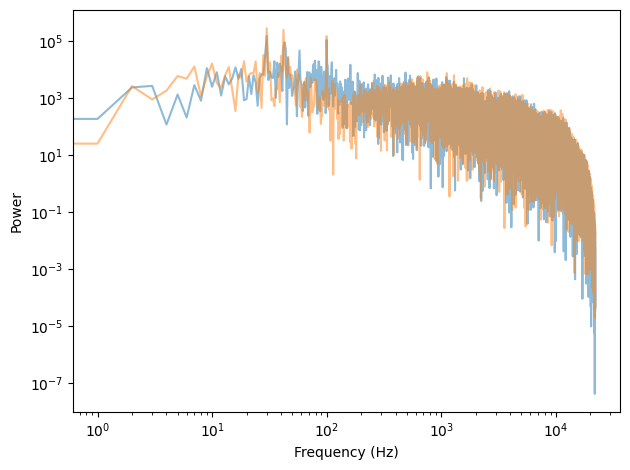

In [29]:
rain_spectrum.plot_power(alpha=0.5)
rain_spectrum2.plot_power(alpha=0.5)
decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

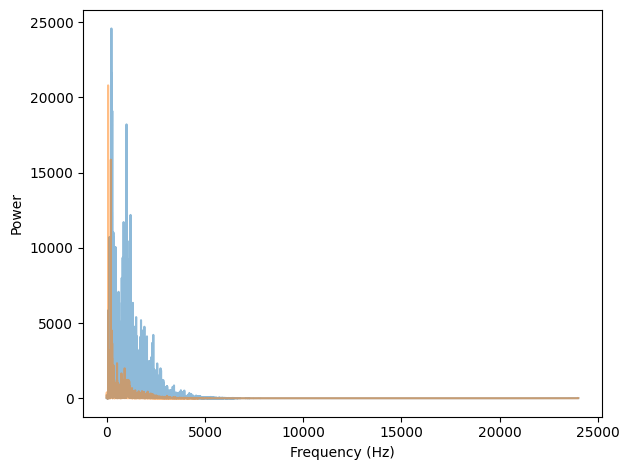

In [30]:
waves_segment2 = waves_wave.segment(start=6.5, duration=1.0)
waves_spectrum2 = waves_segment2.make_spectrum()

waves_spectrum.plot_power(alpha=0.5)
waves_spectrum2.plot_power(alpha=0.5)
decorate(xlabel='Frequency (Hz)', ylabel='Power')

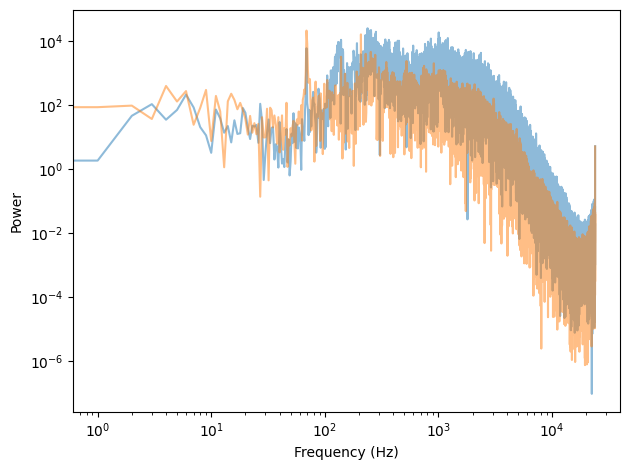

In [31]:
waves_spectrum.plot_power(alpha=0.5)
waves_spectrum2.plot_power(alpha=0.5)
decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

Спектры обоих сигналов почти не меняются во времени.

# **Упражнение 4.2**
В шумовом сигнале частотный состав меняется во времени. На большом интервале мощность на всех частотах одинакова, а на коротком мощность на каждой частоте случайна.

Для оценки долговременной средней мощности на каждой частоте можно разорвать сигнал на сегменты, вычислить спектр мощности для каждого сегмента, а затем найти среднее по сегментам. Об
этом алгоритме можно прочитать подробнее на странице http://en.wikipedia.org/wiki/Bartlett's_method (на англ. яз.).

Реализуйте метод Бартлетта и используйте его для оценки спектра мощности пгумового сигнала. Подсказка: посмотрите на реализацию
make_spectrogram.

In [32]:
from thinkdsp import Spectrum

def bartlett_method(wave, seg_length=512, win_flag=True):
    spectro = wave.make_spectrogram(seg_length, win_flag)
    spectrums = spectro.spec_map.values()

    psds = [spectrum.power for spectrum in spectrums]

    hs = np.sqrt(sum(psds) / len(psds))
    fs = next(iter(spectrums)).fs

    spectrum = Spectrum(hs, fs, wave.framerate)
    return spectrum

Метод Барлета используется для того, чтобы разорвать сигнал на сегменты, вычислить спектр мощности для каждого сегмента и затем найти среднее.

Используем его для оценки спектра мощности шумовой сигнала дождя и волны.

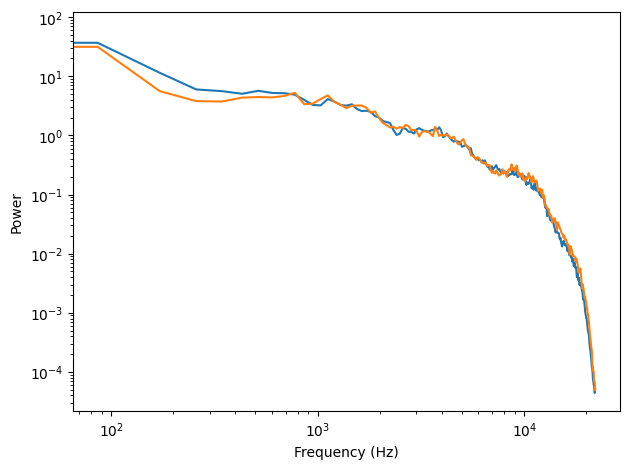

In [33]:
psd = bartlett_method(rain_segment)
psd2 = bartlett_method(rain_segment2)

psd.plot_power()
psd2.plot_power()

decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

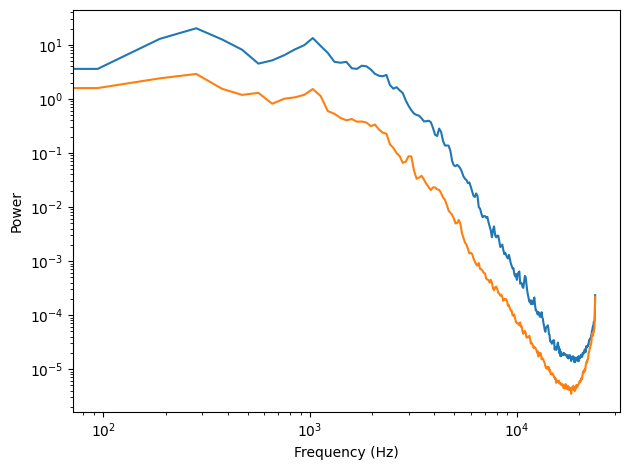

In [34]:
waves_psd = bartlett_method(waves_segment)
waves_psd2 = bartlett_method(waves_segment2)

waves_psd.plot_power()
waves_psd2.plot_power()

decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

Взаимосвязь между мощностью и частотой - не простая линейная зависимость, а она и постоянна в разных сегментах, даже в таких деталях, как выемки.

# **Упражнение 4.3**
На веб-странице http://www.coindesk.com/price можно скачать в виде CSV-файла исторические данные о ежедневной цене BitCoin, откройте этот файл и вычислите спектр цен BitCoin как функцию
времени. Похоже ли это на белый, розовый или броуновский шум?

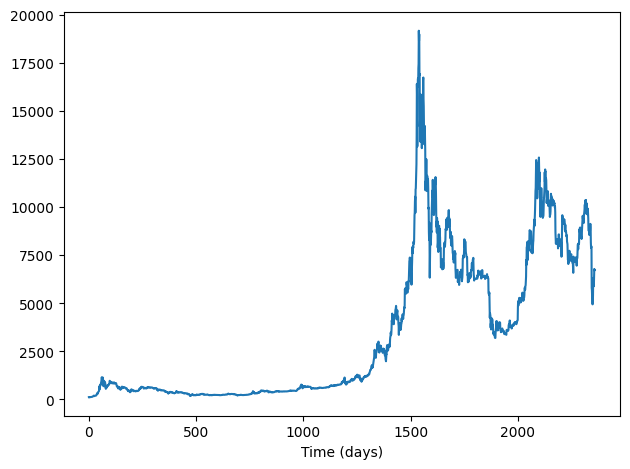

In [36]:
import pandas as pd
from thinkdsp import Wave

df = pd.read_csv('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv')
ys = df['Closing Price (USD)']
ts = df.index

wave = Wave(ys, ts, framerate=1)
wave.plot()
decorate(xlabel='Time (days)')

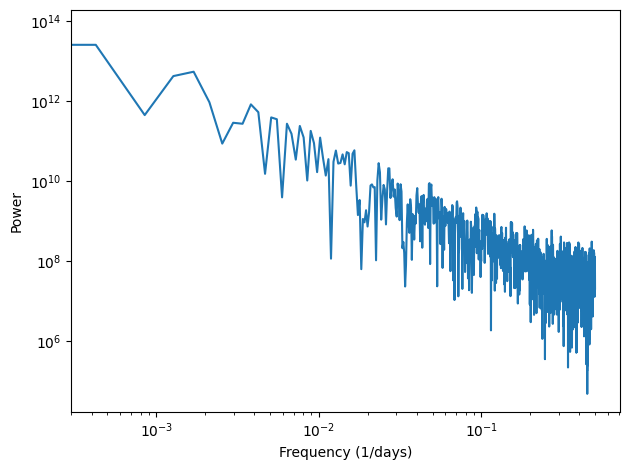

In [37]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (1/days)', ylabel='Power', **loglog)

In [38]:
spectrum.estimate_slope()[0]

np.float64(-1.7332540936758924)

Наклон β = -1.7, что находится в пределах от 0 до -2 => спектр мощности похож на розовый шум

# **Упражнение 4.4**
Счетчик Гейгера — прибор для обнаружения радиации. Когда ионизирующие частицы попадают в детектор, на его выходе появляются импульсы тока. Общий выход в определенный момент времени можно смоделировать некоррелированным пуассоновым шумом (UP), где каждая выборка есть случайное число из распределения Пуассона, соответствующее количеству частиц, обнаруженных за интервал
измерения.

Напишите класс, называемый UncorrelatedPoissonNoise, наследующий thinkdsp. Noise и предоставляющий evaluate. Следует
использовать Np.random.poisson для генерации случайных величин из распределения Пуассона. Параметр этой функции lam — это
среднее число частиц за время каждого интервала. Можно использовать атрибут апр для определения lam. Например, при частоте кадров
10 кГц и апр 0,001 получится около 10 «щелчков» в секунду.

Стенерируйте пару секунд UP и прослушайте. Для малых значений amp, например 0,001, звук будет как у счетчика Гейгера. При больших
значениях он будет похож на белый шум. Вычислите и напечатайте
спектр мощности и посмотрите, так ли это.


In [39]:
from thinkdsp import Noise

class UncorrelatedPoissonNoise(Noise):
    def evaluate(self, ts):
        return np.random.poisson(self.amp, len(ts))

Writing low_wave.wav


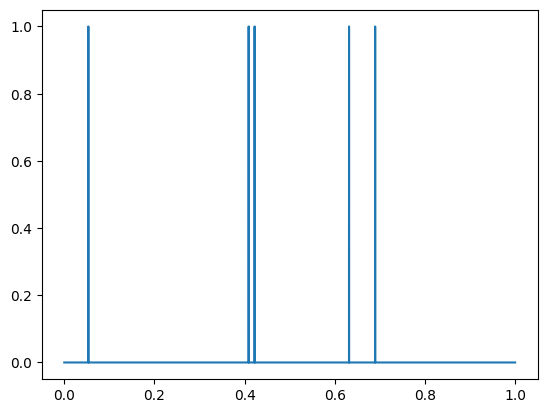

In [40]:
amp = 0.001
framerate = 10000
duration = 1

low_signal = UncorrelatedPoissonNoise(amp=amp)
low_wave = low_signal.make_wave(duration=duration, framerate=framerate)
low_wave.apodize()
low_wave.write("low_wave.wav")
low_wave.plot()

Звук похож на звук счетчика Гейгера.

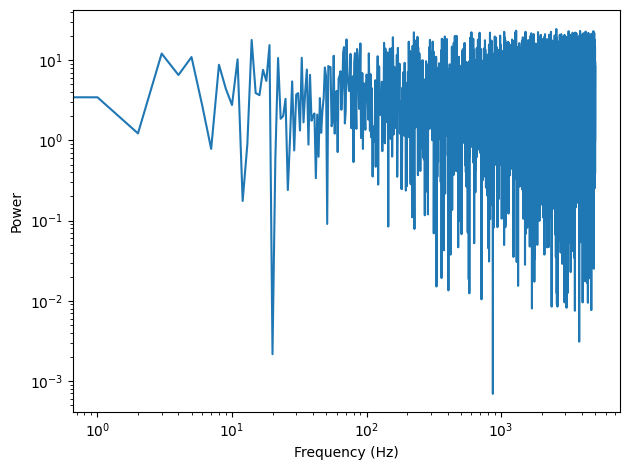

In [41]:
low_spectrum = low_wave.make_spectrum()
low_spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

Writing high_wave.wav


/content/thinkdsp.py:1161: UserWarning: Warning: normalizing before quantizing.
  warnings.warn("Warning: normalizing before quantizing.")


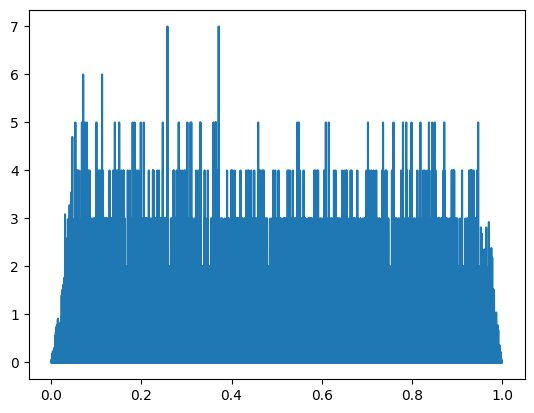

In [42]:
amp = 1
framerate = 10000
duration = 1

high_signal = UncorrelatedPoissonNoise(amp=amp)
high_wave = high_signal.make_wave(duration=duration, framerate=framerate)
high_wave.apodize()
high_wave.write("high_wave.wav")
high_wave.plot()

Звук похож на белый шум.

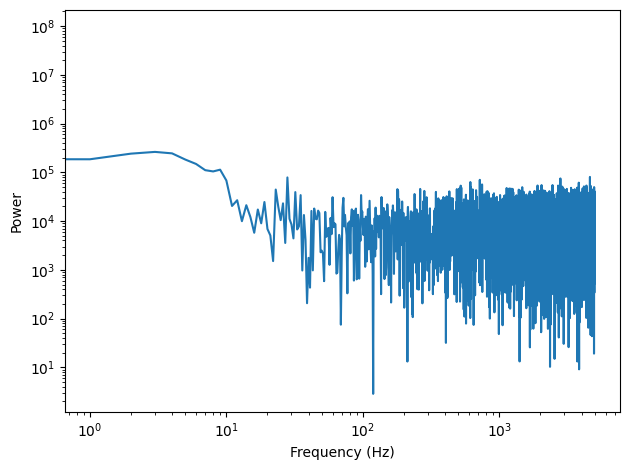

In [45]:
high_spectrum = high_wave.make_spectrum()
high_spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

In [46]:
high_spectrum.estimate_slope().slope

np.float64(-0.052105449258069376)

# **Упражнение 4.5**
В этой главе алгоритм для генерации розового шума концептуально простой, но затратный. Существуют более эффективные варианты, например алгоритм Voss—McCartney. Изучите этот способ, реализуйте его, вычислите спектр результата и убедитесь, что соотношение между мощностью и частотой соответствующее.

Идея алгоритма заключается в сложении нескольких последовательностей случайных чисел, которые обновляются с разной частотой дискретизации. Первый источник должен обновляться на каждом временном шаге; второй источник - через каждый временной шаг, третий источник - через каждый четвертый шаг и так далее

In [48]:
def voss(nrows, ncols=16):
    array = np.empty((nrows, ncols))
    array.fill(np.nan)
    array[0, :] = np.random.random(ncols)
    array[:, 0] = np.random.random(nrows)

    n = nrows
    cols = np.random.geometric(0.5, n)
    cols[cols >= ncols] = 0
    rows = np.random.randint(nrows, size=n)
    array[rows, cols] = np.random.random(n)

    df = pd.DataFrame(array)
    df = df.ffill()
    total = df.sum(axis=1)

    return total.values

Writing pink_wave.wav


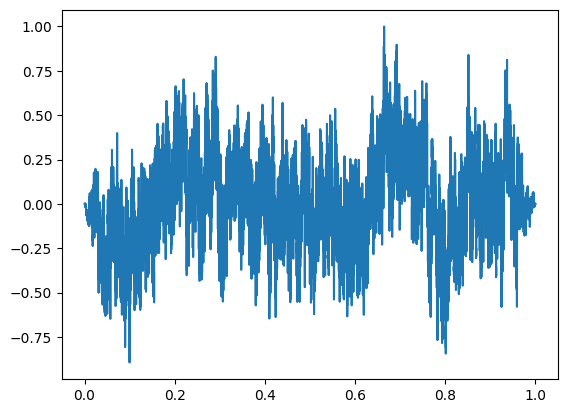

In [49]:
ys = voss(11025)
wave = Wave(ys)
wave.unbias()
wave.normalize()
wave.apodize()
wave.write("pink_wave.wav")
wave.plot()

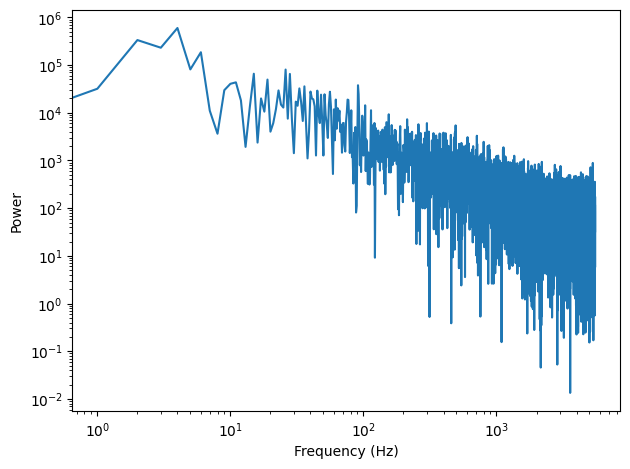

In [50]:
spectrum = wave.make_spectrum()
spectrum.hs[0] = 0
spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', **loglog)

In [51]:
spectrum.estimate_slope().slope

np.float64(-1.0084248562177407)

Наклон β = -1, что находится в пределах от 0 до -2, поэтому спектр мощности похож на розовый шум => убеждаемся, что соотношение между мощностью и частотой соответствующее.